# RT
Load RT data and clean it step by step.

In [40]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

rt_file = BASE_DIR / "RT_de.xlsx"
df = pd.read_excel(rt_file)
df["source"] = "RT_de"
df["source_file"] = rt_file.name

print(f"Loaded {len(df)} rows from {rt_file}")
df.head()

Loaded 12390 rows from /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/RT_de.xlsx


Date                        Category  \
0  2026-01-19    Hauptseite\n/\nInternational   
1  2026-01-19    Hauptseite\n/\nInternational   
2  2026-01-19  Hauptseite\n/\nNahost-Konflikt   
3  2026-01-19          Hauptseite\n/\nSchweiz   
4  2026-01-19    Hauptseite\n/\nInternational   

                                                                                               Title  \
0                            Trump: Dänemark kann "russische Bedrohung" in Grönland nicht beseitigen   
1                                              Mindestens 39 Tote bei schwerem Zugunglück in Spanien   
2          Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin   
3                        Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps   
4  Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen   

                                                                                                                                                                                                                                                                                                                                             Summary  \
0                                                                                       Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die "russische Bedrohung" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht bewältigt, schrieb US-Präsident Donald Trump. Jetzt sei es "an der Zeit", diese Frage zu klären.   
1                                                                                  Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurden verletzt. Die Ursache ist unklar. Der Bahnverkehr zwischen Madrid und Andalusien bleibt ausgesetzt.   
2  Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden. Grund seien die militärischen Ereignisse im Nordosten des Landes. Syrische Medien haben bekannt gegeben, dass mit den kurdischen SDF-Kräften ein Waffenstillstand vereinbart wurde.   
3                                                                                                                              Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor der Eröffnung steht fest: Dieses WEF gehört Donald Trump.   
4                                                   Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante "Friedensrat" der USA verstärkt die Angst vor einer neuen, machtbasierten Weltordnung. Russland wird damit zum Hüter geltender internationaler Regeln.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [41]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Category,0,0.0
Full_Text,0,0.0
URL,0,0.0


In [42]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"
dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= start) & (dates <= end)

df_aug2025_jan2026 = df_clean.loc[mask].copy()
df_aug2025_jan2026["Date"] = pd.to_datetime(df_aug2025_jan2026["Date"])

print(f"Rows in selected period: {len(df_aug2025_jan2026)}")
df_aug2025_jan2026.sort_values("Date").head()

Rows in selected period: 4570


Date                      Category  \
4569 2025-08-01    Hauptseite\n/\nDeutschland   
4555 2025-08-01        Hauptseite\n/\nSchweiz   
4556 2025-08-01  Hauptseite\n/\nInternational   
4557 2025-08-01  Hauptseite\n/\nInternational   
4558 2025-08-01  Hauptseite\n/\nInternational   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [30]:
# keep only the requested columns
_keep = ["Date", "Category", "Full_Text", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

Date                        Category  \
0  2026-01-19    Hauptseite\n/\nInternational   
1  2026-01-19    Hauptseite\n/\nInternational   
2  2026-01-19  Hauptseite\n/\nNahost-Konflikt   
3  2026-01-19          Hauptseite\n/\nSchweiz   
4  2026-01-19    Hauptseite\n/\nInternational   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [22]:
from IPython.display import display
display(df_clean.head(3))

,Date,Category,Full_Text,URL
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht bewältigt, schrieb US-Präsident Donald Trump. Jetzt sei es ""an der Zeit"", diese Frage zu klären.Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf seinem sozialen Netzwerk Truth Social schrieb der amerikanische Staatschef:\n\n""Die NATO sagt Dänemark seit 20 Jahren: 'Ihr müsst die russische Bedrohung in der Region Grönland beseitigen.' Leider war Dänemark nicht in der Lage, etwas dagegen zu unternehmen. Jetzt ist es an der Zeit – und es wird getan werden.""\n\nRussland geht davon aus, dass Grönland dänisches Territorium ist, betonte der Pressesprecher des russischen Präsidenten, Dmitri Peskow.\n\nTrumps Aussagen über russische und chinesische Schiffe vor der Küste der Insel wurden insbesondere von Diplomaten widerlegt, die an den NATO-Sitzungen teilgenommen hatten, berichtete die Financial Times.\n\nDänemark: Tausende protestieren wegen Trumps Ansprüche auf Grönland\n\nSeit seiner Rückkehr ins Weiße Haus im Januar 2025 hat Trump wiederholt erklärt, dass die USA die Kontrolle über Grönland übernehmen sollten. Er begründete seine Ansprüche auf die Insel mit der Notwendigkeit, die nationale Sicherheit der Vereinigten Staaten zu gewährleisten. Dabei schloss der amerikanische Präsident den Einsatz militärischer Gewalt zur Erlangung der Kontrolle über Grönland nicht aus.\n\nVor dem Hintergrund der Annexionsdrohungen beschlossen sechs europäische Länder, darunter Frankreich, Deutschland, Schweden und Norwegen, ihre Truppen nach Grönland zu entsenden. Am 18. Januar berichtete die Bild, dass Berlin seine Soldaten ohne Angabe von Gründen heimlich abgezogen habe.\n\nEinen Tag zuvor hatte Trump die Einführung eines Zolls von zehn Prozent auf Waren aus Dänemark, Norwegen, Schweden, Frankreich, Deutschland, Großbritannien, den Niederlanden und Finnland angekündigt. Der US-Präsident erklärte, dass die europäischen Länder so lange Zölle zahlen würden, bis eine Einigung über den Kauf Grönlands erzielt sei. Ab dem 1. Juni werde der Zollsatz auf 25 Prozent steigen, fügte er hinzu.\n\nMehr zum Thema – Wegen Grönland – Trump verhängt Strafzölle gegen Deutschland und EU-Partner",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/
1,2026-01-19,Hauptseite\n/\nInternational,"Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurden verletzt. Die Ursache ist unklar. Der Bahnverkehr zwischen Madrid und Andalusien bleibt ausgesetzt.Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen schwer.\n\nDer Unfall ereignete sich am Sonntagabend auf der Hochgeschwindigkeitsstrecke zwischen Málaga und Madrid nahe der Gemeinde Adamuz in der Provinz Córdoba.\n\nNach Angaben der Polizei entgleiste zunächst ein Hochgeschwindigkeitszug des privaten Anbieters Iryo, der von Málaga in Richtung Madrid unterwegs war.\n\nTragedy in southern Spain🇪🇸: a high-speed train derailed, crossed tracks, and hit another train head-on.More than 21 reportedly killed, and at least 100 injured, with 25 suffering critical injuries#Spain | #trainaccidentpic.twitter.com/UHas6y2Luk\n\n— Sumit (@SumitHansd) January 19, 2026\n\nDer hintere Teil des Zuges geriet auf ein Gegengleis und kollidierte dort mit einem entgegenkommenden Fernzug der staatlichen Bahn Renfe.\n\nIn der Folge entgleisten mehrere Waggons beider Züge, einige stürzten eine Böschung hinab. Unter den Todesopfern befindet sich auch einer der Lokführer.\n

Removal of "Mehr zum Thema"

In [43]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Full_Text"] = df_clean["Full_Text"].apply(remove_mehr_zum_thema)

In [44]:
df_clean.head()

Date                        Category  \
0  2026-01-19    Hauptseite\n/\nInternational   
1  2026-01-19    Hauptseite\n/\nInternational   
2  2026-01-19  Hauptseite\n/\nNahost-Konflikt   
3  2026-01-19          Hauptseite\n/\nSchweiz   
4  2026-01-19    Hauptseite\n/\nInternational   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [34]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 22.1 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 29.1 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Full_Text" if "Full_Text" in eda_df.columns else "Text"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 12,390


In [46]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    12390.0
mean       615.5
std        415.4
min          7.0
10%        281.0
25%        347.0
50%        456.0
75%        738.0
90%       1233.1
95%       1480.0
99%       1998.0
max       4689.0
Name: article_length_words, dtype: float64

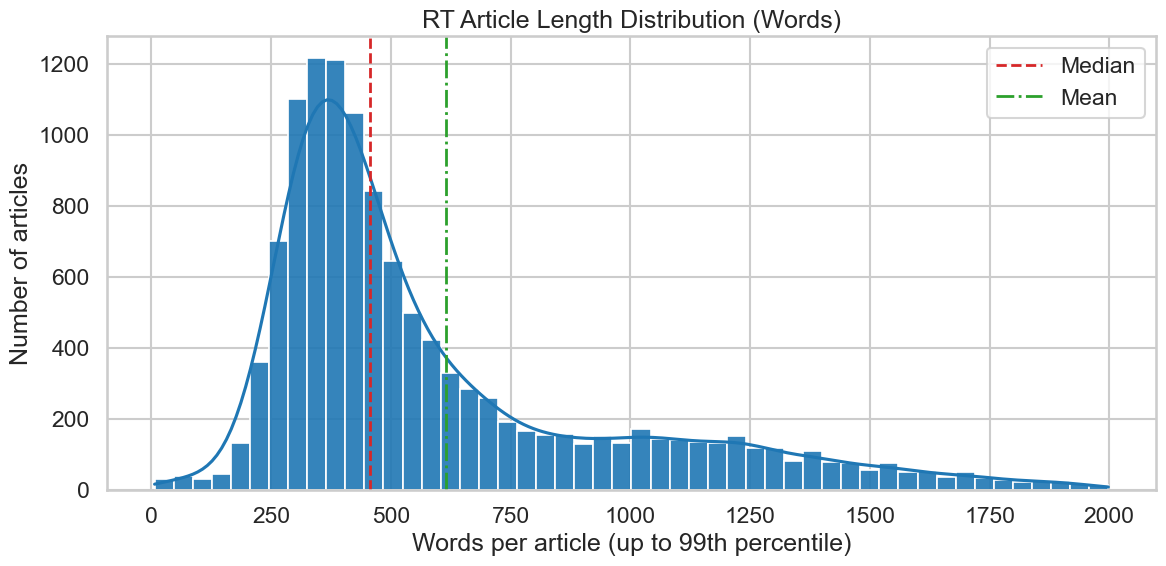

In [47]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
daily_counts = (
    eda_df.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()

,Date,articles,rolling_7d
0,2024-11-14,24,24.0
1,2024-11-15,24,24.0
2,2024-11-16,24,24.0
3,2024-11-17,20,23.0
4,2024-11-18,30,24.4


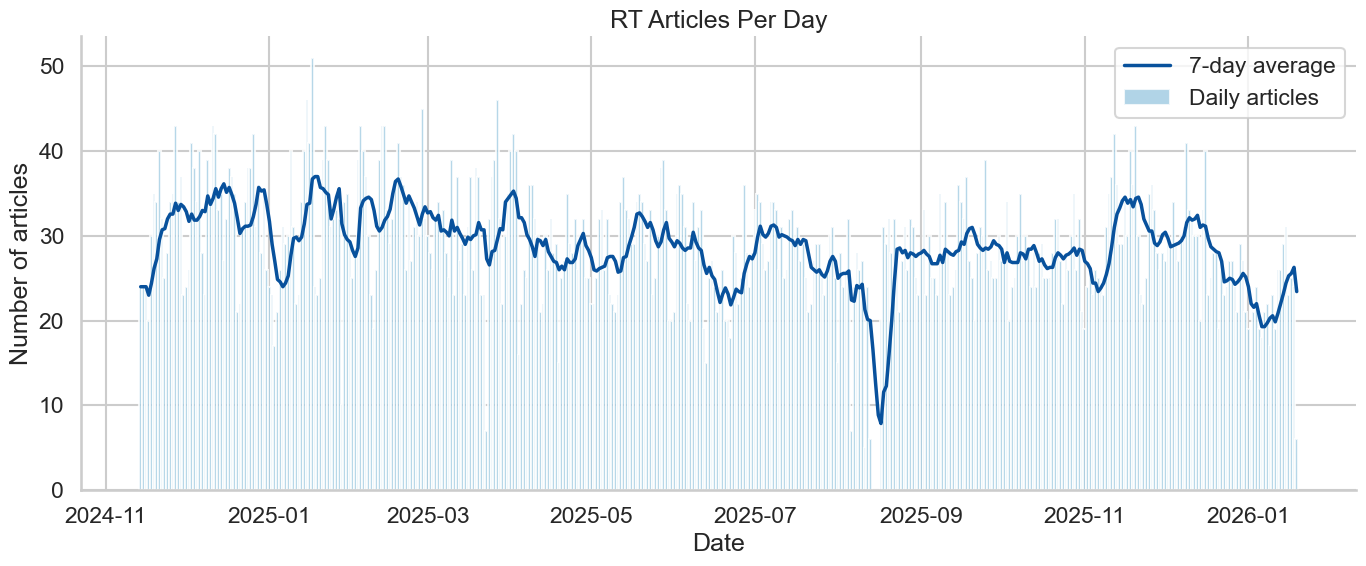

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()